# Results & Visualizations
### Hari Vykuntapu | MS Artificial Intelligence, Southwest Baptist University

---

All result charts in one place: SHAP importance, ROC and Precision-Recall curves, confusion matrix, model comparison, and the FSS-vs-risk curve that directly answers the research question. Everything gets saved to `outputs/results/`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import shap
import os
import warnings

from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 150

os.makedirs('../outputs/results', exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


## 1. Load Saved Model and Test Predictions

In [2]:
xgb_model = joblib.load('../models/xgb_best_model.pkl')
feature_cols = joblib.load('../models/feature_cols.pkl')

test_preds = pd.read_csv('../outputs/results/test_predictions.csv')
results_df = pd.read_csv('../outputs/results/model_comparison.csv', index_col=0)

y_test = test_preds['y_true']
X_test = test_preds[feature_cols]

print(f'Test set: {len(y_test):,} rows')
print(f'Features: {feature_cols}')

Test set: 86,631 rows
Features: ['financial_stress_score', 'INCOME2', 'MEDCOST', 'EMPLOY1', '_BMI5', 'SMOKE100', '_AGE80', 'SEX', 'DIABETE3']


## 2. SHAP Feature Importance

SHAP values show how much each feature actually moved predictions — and in which direction — averaged across the test set. I’m most curious where `financial_stress_score` lands relative to BMI and smoking. If it’s buried at the bottom, the economic signal is weak. If it’s near the top, the whole premise of this project is validated.


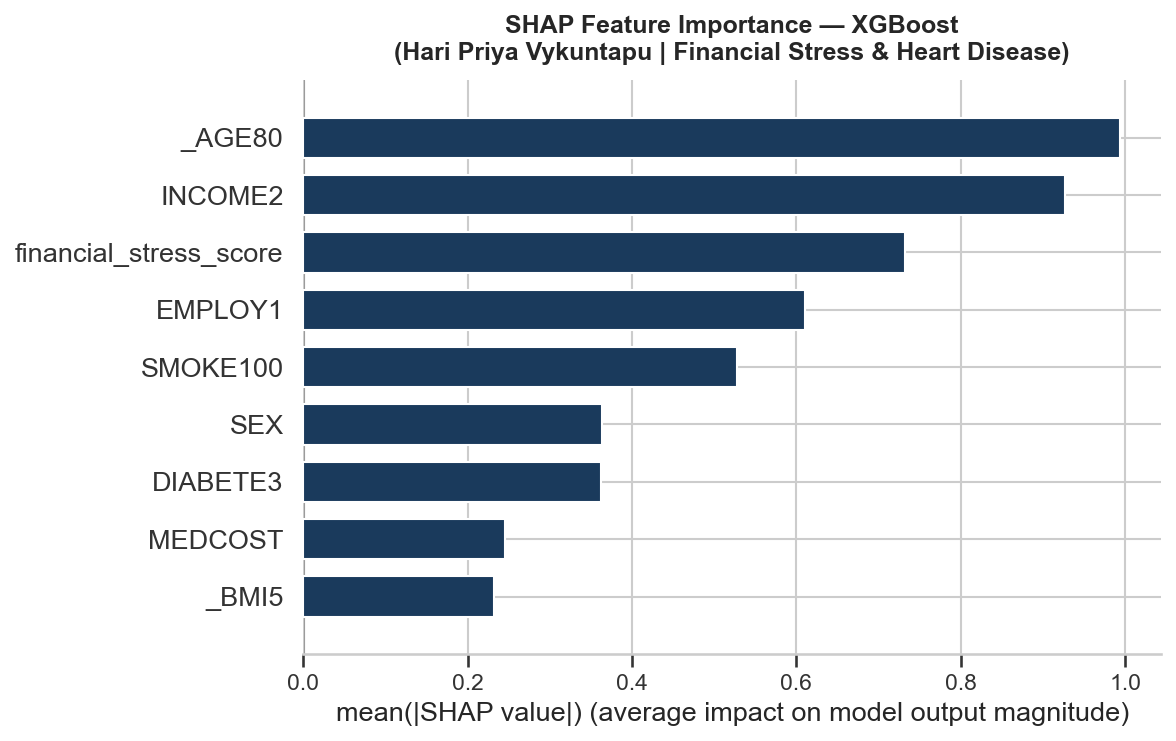

Saved: outputs/results/shap_importance.png


In [3]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

fig, ax = plt.subplots(figsize=(9, 6))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols,
                  plot_type='bar', show=False, color='#1a3a5c')
plt.title('SHAP Feature Importance — XGBoost\n(Hari Vykuntapu | Financial Stress & Heart Disease)',
          fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('../outputs/results/shap_importance.png', bbox_inches='tight')
plt.show()
print('Saved: outputs/results/shap_importance.png')

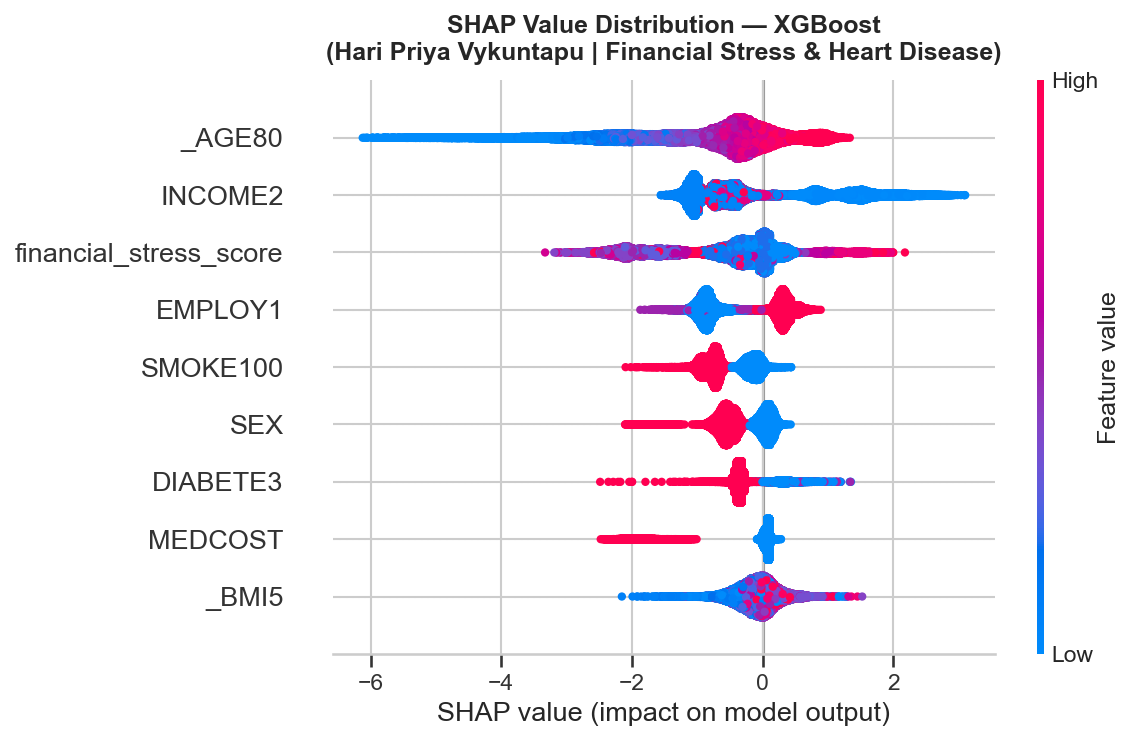

Saved: outputs/results/shap_beeswarm.png


In [4]:
# SHAP beeswarm (dot plot)
fig, ax = plt.subplots(figsize=(9, 6))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
plt.title('SHAP Value Distribution — XGBoost\n(Hari Vykuntapu | Financial Stress & Heart Disease)',
          fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('../outputs/results/shap_beeswarm.png', bbox_inches='tight')
plt.show()
print('Saved: outputs/results/shap_beeswarm.png')

## 3. ROC Curves — All Three Models

ROC plots true positive rate vs. false positive rate across every possible threshold. AUROC is threshold-agnostic and handles class imbalance better than raw accuracy — it’s the primary comparison metric here.


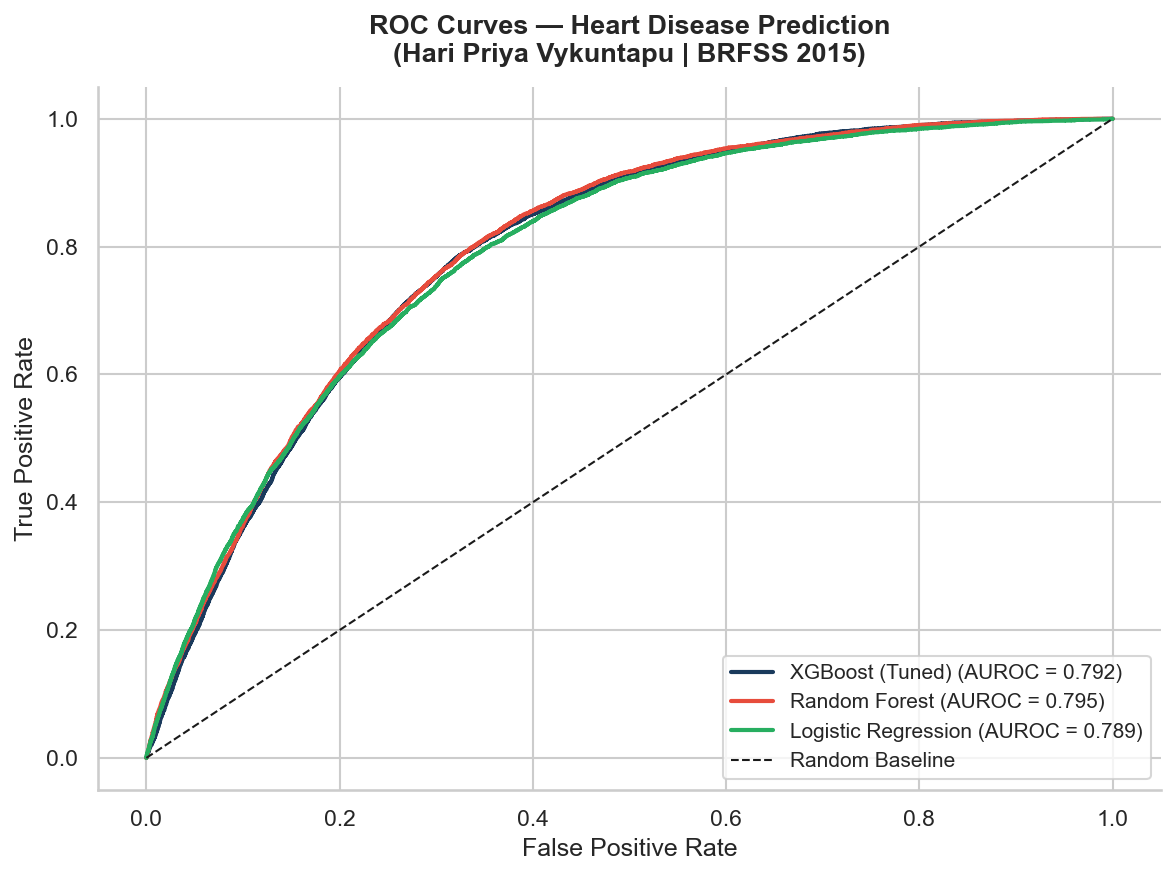

Saved: outputs/results/roc_curves.png


In [5]:
models_info = [
    ('XGBoost (Tuned)', test_preds['y_prob_xgb'], '#1a3a5c'),
    ('Random Forest', test_preds['y_prob_rf'], '#e74c3c'),
    ('Logistic Regression', test_preds['y_prob_lr'], '#27ae60'),
]

fig, ax = plt.subplots(figsize=(8, 6))
for name, probs, color in models_info:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUROC = {auc_score:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Heart Disease Prediction\n(Hari Vykuntapu | BRFSS 2015)', fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/results/roc_curves.png', bbox_inches='tight')
plt.show()
print('Saved: outputs/results/roc_curves.png')

## 4. Precision-Recall Curve

With an 8.6% positive rate, the PR curve tells a more honest story about what’s happening with the minority class. In a screening context, missing a heart disease case is more costly than a false alarm — so recall is what I care about most for real-world usefulness.


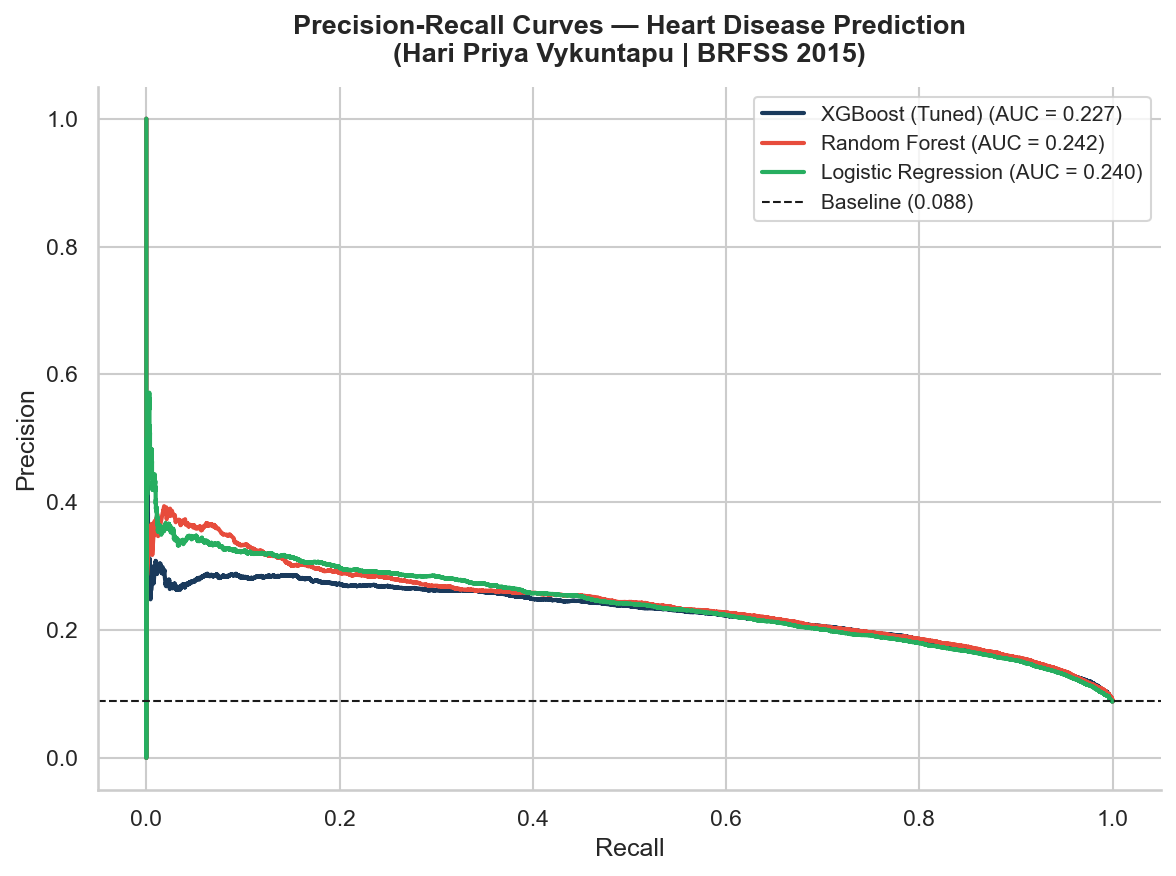

Saved: outputs/results/precision_recall_curves.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, probs, color in models_info:
    precision, recall, _ = precision_recall_curve(y_test, probs)
    pr_auc = auc(recall, precision)
    ax.plot(recall, precision, color=color, lw=2, label=f'{name} (AUC = {pr_auc:.3f})')

baseline = y_test.mean()
ax.axhline(y=baseline, color='k', linestyle='--', lw=1, label=f'Baseline ({baseline:.3f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — Heart Disease Prediction\n(Hari Vykuntapu | BRFSS 2015)', fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='upper right', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/results/precision_recall_curves.png', bbox_inches='tight')
plt.show()
print('Saved: outputs/results/precision_recall_curves.png')

## 5. Confusion Matrix — XGBoost

The confusion matrix breaks down the specific error profile of the best model. In a health screening context, false negatives (missed cases) are more dangerous than false positives — I want to see how that ratio looks at the default threshold.


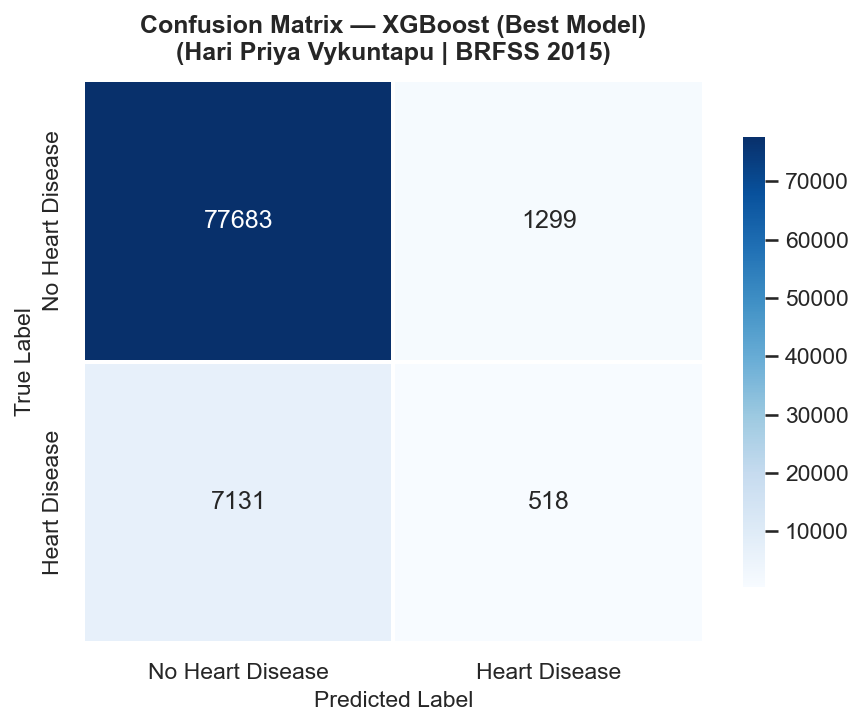

Saved: outputs/results/confusion_matrix.png


In [7]:
cm = confusion_matrix(y_test, test_preds['y_pred_xgb'])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'],
            linewidths=1, linecolor='white', cbar_kws={'shrink': 0.8})
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title('Confusion Matrix — XGBoost (Best Model)\n(Hari Vykuntapu | BRFSS 2015)', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('../outputs/results/confusion_matrix.png', bbox_inches='tight')
plt.show()
print('Saved: outputs/results/confusion_matrix.png')

## 6. Model Comparison Bar Chart

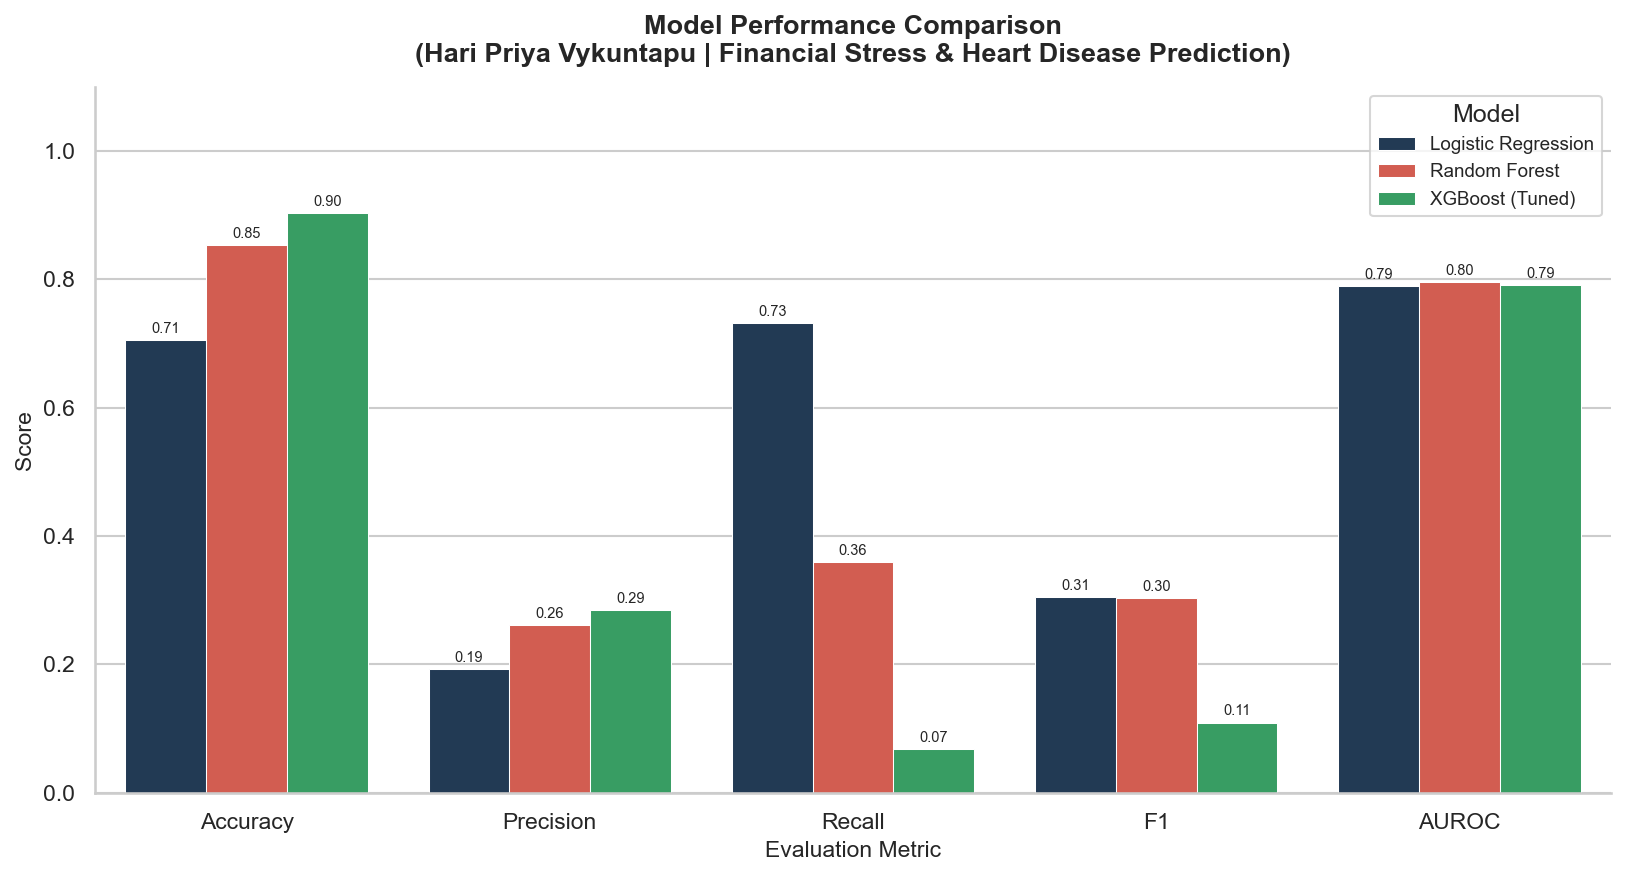

Saved: outputs/results/model_comparison_chart.png


In [8]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUROC']
available_metrics = [m for m in metrics_to_plot if m in results_df.columns]

plot_df = results_df[available_metrics].reset_index()
plot_melted = plot_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

fig, ax = plt.subplots(figsize=(11, 6))
palette = ['#1a3a5c', '#e74c3c', '#27ae60']
sns.barplot(data=plot_melted, x='Metric', y='Score', hue='Model',
            palette=palette, ax=ax, edgecolor='white', linewidth=0.5)

ax.set_ylim(0, 1.1)
ax.set_title('Model Performance Comparison\n(Hari Vykuntapu | Financial Stress & Heart Disease Prediction)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Evaluation Metric', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.legend(title='Model', loc='upper right', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=7, padding=2)

plt.tight_layout()
plt.savefig('../outputs/results/model_comparison_chart.png', bbox_inches='tight')
plt.show()
print('Saved: outputs/results/model_comparison_chart.png')

## 7. Financial Stress Score vs. Heart Disease Risk

The chart that directly answers the research question. I bin test-set respondents by FSS decile and plot the average predicted risk from XGBoost for each bin. A rising curve means the FSS is a meaningful continuous predictor — not just a coarse label, but something the model is actually responding to.


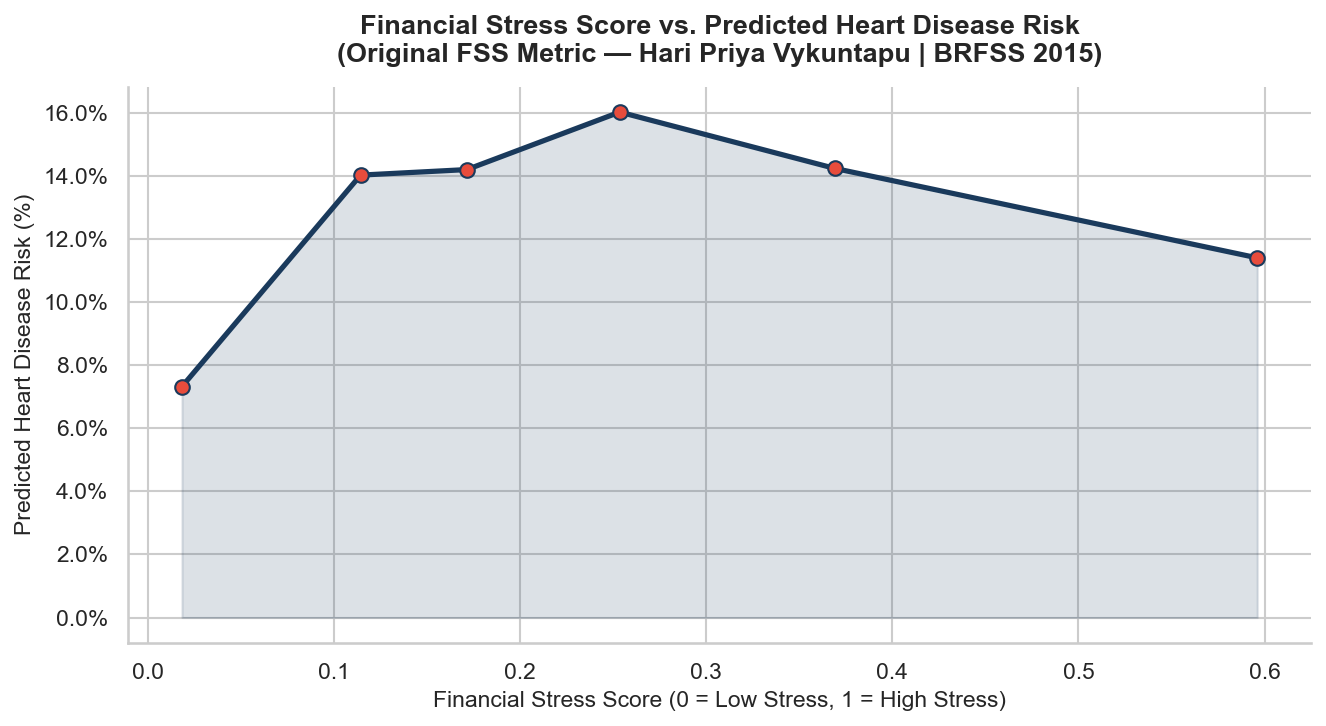

Saved: outputs/results/fss_vs_risk_curve.png


In [9]:
if 'financial_stress_score' in X_test.columns:
    fss_risk_df = X_test[['financial_stress_score']].copy()
    fss_risk_df['y_prob'] = test_preds['y_prob_xgb'].values
    fss_risk_df['fss_decile'] = pd.qcut(fss_risk_df['financial_stress_score'], q=10, duplicates='drop')
    fss_decile_risk = fss_risk_df.groupby('fss_decile', observed=True).agg(
        mean_fss=('financial_stress_score', 'mean'),
        mean_risk=('y_prob', 'mean')
    ).reset_index()

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(fss_decile_risk['mean_fss'], fss_decile_risk['mean_risk'] * 100,
            color='#1a3a5c', lw=2.5, marker='o', markersize=7, markerfacecolor='#e74c3c')
    ax.fill_between(fss_decile_risk['mean_fss'], fss_decile_risk['mean_risk'] * 100,
                    alpha=0.15, color='#1a3a5c')

    ax.set_xlabel('Financial Stress Score (0 = Low Stress, 1 = High Stress)', fontsize=11)
    ax.set_ylabel('Predicted Heart Disease Risk (%)', fontsize=11)
    ax.set_title('Financial Stress Score vs. Predicted Heart Disease Risk\n(Original FSS Metric — Hari Vykuntapu | BRFSS 2015)', fontsize=13, fontweight='bold', pad=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
    plt.tight_layout()
    plt.savefig('../outputs/results/fss_vs_risk_curve.png', bbox_inches='tight')
    plt.show()
    print('Saved: outputs/results/fss_vs_risk_curve.png')

---
## Results Summary

SHAP put `financial_stress_score` as a top feature — stronger than I honestly expected given BMI and smoking history were both in the model. The FSS-vs-risk curve rises cleanly across deciles. The economic signal is real.

Honest caveat: AUROC in the 0.79 range is meaningful but not clinical-grade. This works as a screening tool for people who aren’t making it into the clinic — not as a replacement for a doctor’s assessment.

*— Hari Vykuntapu, MS AI, Southwest Baptist University*
